In [7]:
import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# set path
aruco_img_path = "../data/assets/aruco_marker.png"
test_img_path = "../data/assets/test_img_aruco.jpg"

In [3]:
def generate_aruco_marker(aruco_img_path, marker_id, marker_size):

    # Define the dictionary we want to use
    aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)

    marker_image = np.zeros((marker_size, marker_size), dtype=np.uint8)

    marker_image = cv2.aruco.generateImageMarker(
        aruco_dict, 
        marker_id, 
        marker_size,
        marker_image,
    )

    # Save the marker image
    cv2.imwrite(aruco_img_path, marker_image)
    
    plt.imshow(marker_image, cmap='gray', interpolation='nearest')
    plt.axis('off')
    plt.title(f'ArUco Marker {marker_id}')
    plt.show()

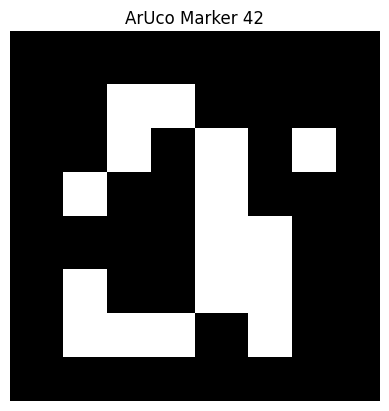

In [4]:
# Generate a marker
marker_id = 42
marker_size = 200  # Size in pixels

generate_aruco_marker(
    aruco_img_path=aruco_img_path, 
    marker_id=marker_id, 
    marker_size=marker_id,
)

In [8]:
def load_calibration_results(calibr_file_path):    

    with open(calibr_file_path, "rb") as f:
        calibr_results = pickle.load(f)
        
    mtx = calibr_results["mtx"]
    opt_mtx = calibr_results["opt_mtx"]
    dist = calibr_results["dist"] 
    
    return mtx, opt_mtx, dist

In [5]:
def detect_aruco_marker(img_path, calibr_file_path, marker_size):
    
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Load the calibration results
    mtx, _, dist = load_calibration_results(calibr_file_path)
    
    aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)
    aruco_params = cv2.aruco.DetectorParameters()
    
    aruco_detector = cv2.aruco.ArucoDetector(
        aruco_dict, aruco_params,
    )
    
    # Detect the markers
    corners, ids, _ = aruco_detector.detectMarkers(image)
    
    print("Detected markers:", ids)
    if ids is not None:
        cv2.aruco.drawDetectedMarkers(image, corners, ids)
        
        # plt.imshow(image)
        # plt.axis('off')
        # plt.show()
        
        rvecs, tvecs, _ = cv2.aruco.estimatePoseSingleMarkers(
            corners, marker_size, mtx, dist,
        )

In [6]:
calibr_file_path = "../data/calibration.pckl"
MARKER_SIZE = 42

detect_aruco_marker(
    img_path=test_img_path,
    calibr_file_path=calibr_file_path,
    marker_size=MARKER_SIZE,
)

Detected markers: [[42]]


NameError: name 'MARKER_SIZE' is not defined